## Predictions : Distance based models

In [1]:
### autoreloader
%load_ext autoreload
%autoreload 2

In [2]:
### importing the system path
import sys
sys.path.append('../')

In [3]:
### importing the functions from the src
from src.data.load_data import load_data, get_info, get_nan_duplicates_shape, get_shape, drop_col
from src.processing.split_data import split_data_local
from src.predictions.predictions_plot import verify_split, model_predict_test, best_model_predict_valid, other_model_predict_valid

In [4]:
### importing the models to be used for the predictions
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

##### =========== Train data first ====================

In [5]:
### setting up the data path
train_distance_path = '../data/model_ready/train_distance.csv'

In [6]:
### loading the data
train_distance = load_data(train_distance_path)
train_distance.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Fraud_Label,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,0,0,0,1,0,0,0,0,0,...,1.00,0.592437,0.734863,0.366737,0,1,0.272727,0.400000,0.695652,0.424444
1,1,0,0,1,0,0,1,0,0,1,...,0.25,0.130252,0.159358,0.486549,0,0,0.181818,0.866667,0.217391,0.577225
2,0,0,0,0,1,0,0,1,0,1,...,0.50,0.848739,0.457245,0.296030,1,0,0.727273,0.866667,1.000000,0.254520
3,0,1,0,1,0,0,0,0,0,0,...,0.50,0.571429,0.985009,0.336134,0,0,0.727273,0.300000,0.565217,0.490544
4,0,1,0,1,0,0,0,1,0,0,...,0.25,0.029412,0.984885,0.080308,0,0,0.000000,0.400000,0.260870,0.307802


In [7]:
### checking the shape of the data
get_shape(train_distance)

(40000, 34)


In [13]:
### splitting the data into the train/test data
X_train, X_test, y_train, y_test = split_data_local(train_distance, target_feature = 'Fraud_Label')

In [10]:
### veryfying the split
verify_split(X_train, X_test, y_train, y_test)

X_train : (30000, 33) :: X_test : (10000, 33) :: y_train : (30000,) :: y_test : (10000,)


In [14]:
### X_train.head
X_train.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
26898,0,0,1,1,0,0,0,0,1,0,...,0.076857,0.25,0.235294,0.421063,0.248925,0,0.090909,0.533333,0.695652,0.334649
27635,1,0,0,0,1,1,0,0,0,0,...,0.707408,0.25,0.903361,0.780478,0.844584,0,1.000000,0.766667,0.217391,0.100992
3036,0,1,0,1,0,0,1,0,0,0,...,0.392918,1.00,0.722689,0.812198,0.946195,0,0.545455,0.866667,0.086957,0.380925
5604,0,0,0,0,1,0,1,0,0,0,...,0.990449,0.50,0.470588,0.128506,0.984398,0,0.636364,0.700000,0.434783,0.403795
36111,0,0,0,0,1,1,0,0,0,0,...,0.522469,0.50,0.634454,0.653502,0.615062,0,0.818182,0.433333,0.521739,0.503441


In [15]:
### y_test.head()
y_test.head()

32823    0
16298    0
28505    1
6689     0
26893    0
Name: Fraud_Label, dtype: int64

##### predictions

Accuracy score : 0.8093
Confusion matrix : 
[[6018  800]
 [1107 2075]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      6818
           1       0.72      0.65      0.69      3182

    accuracy                           0.81     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.81      0.81      0.81     10000



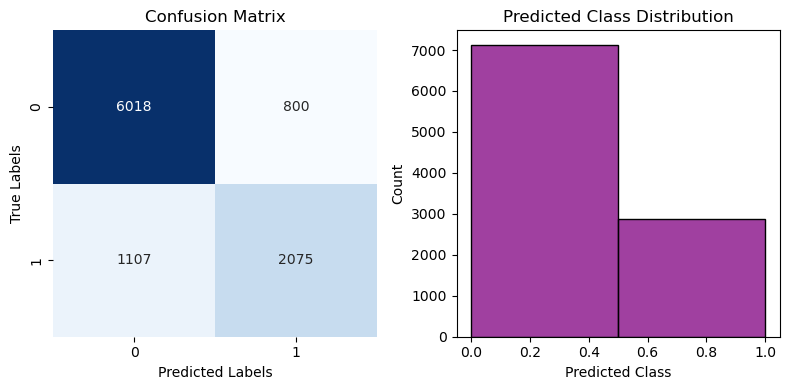

In [18]:
### 1. Logistic regression
lr = LogisticRegression()
lr_path = '../models/distance/lr.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = lr, model_path = lr_path)

Accuracy score : 0.9571
Confusion matrix : 
[[6566  252]
 [ 177 3005]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      6818
           1       0.92      0.94      0.93      3182

    accuracy                           0.96     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.96      0.96      0.96     10000



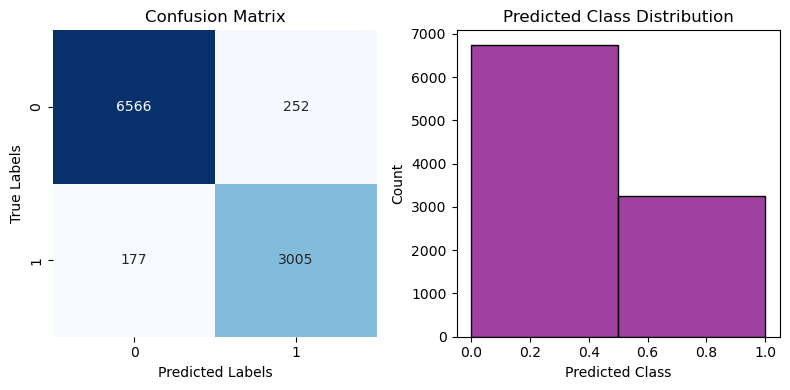

In [20]:
### 2. SVC
svc = SVC()
svc_path = '../models/distance/svc.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = svc, model_path = svc_path)

Accuracy score : 0.7234
Confusion matrix : 
[[6183  635]
 [2131 1051]]
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      6818
           1       0.62      0.33      0.43      3182

    accuracy                           0.72     10000
   macro avg       0.68      0.62      0.62     10000
weighted avg       0.71      0.72      0.69     10000



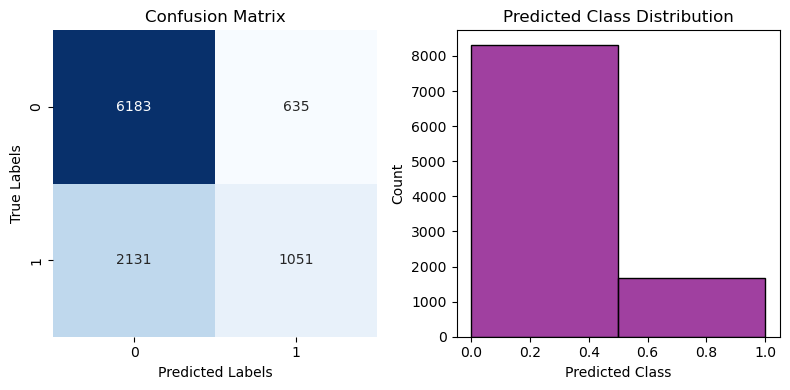

In [21]:
### 3. KNN
knn = KNeighborsClassifier()
knn_path = '../models/distance/knn.pkl'
model_predict_test(X_train, X_test, y_train, y_test, model = knn, model_path = knn_path)

##### =============== Valid Data ===================

In [22]:
### setting up the data path
valid_distance_path = '../data/model_ready/valid_distance.csv'

In [23]:
### loading the data
valid_distance = load_data(valid_distance_path)
valid_distance.head()

,Transaction_Type_Bank Transfer,Transaction_Type_Online,Transaction_Type_POS,Device_Type_Mobile,Device_Type_Tablet,Location_Mumbai,Location_New York,Location_Sydney,Location_Tokyo,Merchant_Category_Electronics,...,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Age,Transaction_Distance,Risk_Score,Is_Weekend,Timestamp_month,Timestamp_day,Timestamp_hour,Transaction_Amount_boxcox
0,0,1,0,1,0,0,0,1,0,0,...,0.694722,0.75,0.894958,0.913818,0.686537,1,0.090909,0.300000,0.086957,0.265145
1,1,0,0,1,0,0,1,0,0,0,...,0.075779,0.25,0.323529,0.059363,0.532206,1,0.181818,0.833333,0.956522,0.371321
2,0,0,0,0,0,0,0,0,1,0,...,0.306400,0.50,0.243697,0.958614,0.492398,0,0.636364,0.133333,0.521739,0.324475
3,0,0,1,0,1,1,0,0,0,0,...,0.674252,1.00,0.596639,0.663668,0.550310,0,0.000000,0.700000,0.826087,0.336945
4,1,0,0,0,1,0,0,1,0,0,...,0.285297,0.00,0.949580,0.114540,0.220744,0,0.636364,0.633333,0.521739,0.407352


In [24]:
### checking the shape
get_shape(valid_distance)

(10000, 33)

##### best model : SVC (predictions on valid)

In [25]:
### 'SVC' predictions on 'valid_tree'
svc_inference_path = '../models/distance/svc.pkl'
y_pred_best = best_model_predict_valid(valid_distance, svc_inference_path)

In [26]:
### checking the 'y_pred_best'
y_pred_best

array([1, 0, 0, ..., 0, 0, 1], dtype=int64)

##### other model predictions (on valid data)

Accuracy score : 0.8306
Confusion matrix : 
[[6022  609]
 [1085 2284]]
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      6631
           1       0.79      0.68      0.73      3369

    accuracy                           0.83     10000
   macro avg       0.82      0.79      0.80     10000
weighted avg       0.83      0.83      0.83     10000



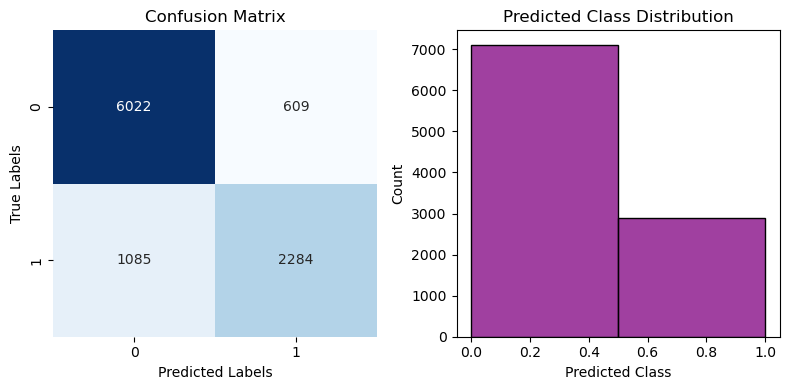

In [27]:
### 1. Logistic Regression
lr_inference_path = '../models/distance/lr.pkl'
other_model_predict_valid(valid_distance, y_pred_best, other_model_path = lr_inference_path)

Accuracy score : 0.7223
Confusion matrix : 
[[6067  564]
 [2213 1156]]
              precision    recall  f1-score   support

           0       0.73      0.91      0.81      6631
           1       0.67      0.34      0.45      3369

    accuracy                           0.72     10000
   macro avg       0.70      0.63      0.63     10000
weighted avg       0.71      0.72      0.69     10000



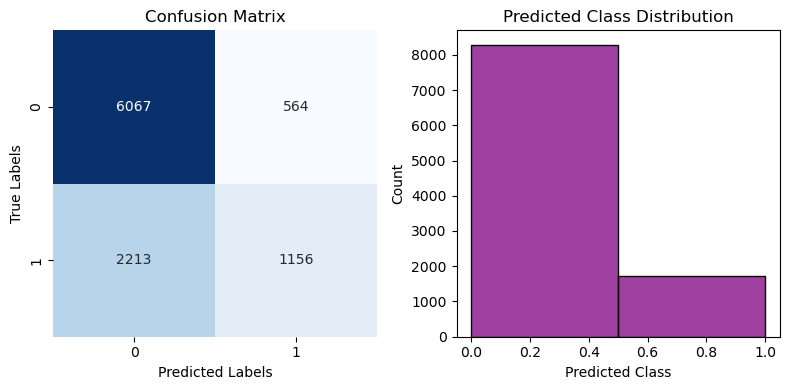

In [28]:
### 2. KNN
knn_inference_path = '../models/distance/knn.pkl'
other_model_predict_valid(valid_distance, y_pred_best, other_model_path = knn_inference_path)